# Sweep top-N ensemble — SHAMe OOD mock (noisy model)

**Noisy** `rand30` sweep (`biasnoisenest` + `noise_unit`) for **$P_{gg}+B+P_{gm}$** with fiducial bispec mask ($k_\text{max}^\text{bispec}=0.25$). Loads the **top 5** stall-passing runs for contours and an **equal-weight mixture of the top 3** by $\ell_\mathrm{val}$, then **reads** precomputed SHAMe OOD posteriors from `submit_inf_test.sh` / `run_inference.py` (`samples_test<tag_test>_pred.npy` under each sweep run dir).

**Prerequisite:** `choose_best_run.py --n-passing N`, then OOD inference jobs (one per `nth_best_run` 0..N−1), e.g. `generate_config_inference.py` + `submit_inf_test.sh`.

**No inference in this notebook** — missing sample files raise an error.

**Fiducial $k_\mathrm{max}$ retraining:** the last section retrains the top 5 stall-passing networks (lowest $\ell_\mathrm{val}$) at $k_\mathrm{max}^\mathrm{bispec}=k_\mathrm{max}^{P_{gm}}=0.25$ for contours; ensemble = $\frac{1}{3}\sum_{j=1}^{3} q_{\varphi_j}(\theta\mid x)$. Train/test with `code/submit_inf_train_test_topn_kfid.sh`.

In [22]:
import csv
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot
import utils_inference

from choose_best_run import (
    build_sweep_tag_inf,
    sweep_root_for_tag_inf,
    BEST_RUN_LOG_CSV,
)
from generate_config_inference import (
    tags_mask_for_sweep,
    resolve_train_tag_bundle,
    resolve_test_scenario_tags,
    TAG_MASK_BISPEC_SWEEP,
    build_tag_data,
)

%matplotlib inline

In [23]:
# --- Problem setup: pk + bispec + pgm, noisy rand30 sweep ---
NOISE_MODE = "noisy"
bx = 32
n_train = 10000
N_ENSEMBLE_K = 3
N_TOP = 5  # individual contours
# Pool size for equal-weight ensemble (subsampled from loaded files)
N_ENSEMBLE = 1000

data_mode = "muchisimocks"
TAG_SWEEP = "-rand30"
tag_reparam = "_rp"

statistics = ["pk", "bispec", "pgm"]
tags_mask = tags_mask_for_sweep(statistics)

train_bundle = resolve_train_tag_bundle("_p5_n10000", NOISE_MODE)
TAG_PARAMS_TRAIN = train_bundle["tag_params"]
TAG_BIASPARAMS_TRAIN = train_bundle["tag_biasparams"]
TAG_NOISE_TRAIN = train_bundle["tag_noise"]

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"
NBAR_LABEL = "0.00022"

PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1"]
idx_obs = 0

extents = {**genp.get_bounds("cosmo"), **genp.get_bounds("bias")}
extents_mid = extents.copy()
extents_mid["b1"] = [-0.4, 1.4]
extents_narrow = extents.copy()
extents_narrow["b1"] = [0.3, 0.6]
extents_narrow["sigma8_cold"] = [0.7, 0.9]  # fixed-cosmo mean only — too high for SHAMe OOD (~0.68)

# SHAMe OOD posteriors sit below 0.7 in sigma8; use extents_mid (see 2026-04-22 SHAMe notebook).
EXTENTS_CORNER = extents_mid

FIGSIZE_CORNER = (6.5, 6.5)
FONTSIZE_LEGEND = 11
LOC_LEGEND = (1.02, 0.98)
LVAL_CMAP = "turbo"  # high-contrast sequential map for top-N contour colors
LVAL_CMAP_MAX = 0.7  # use turbo[0:0.7] so top-N lines are more distinct
LABEL_ENSEMBLE = rf"ensemble $\frac{{1}}{{{N_ENSEMBLE_K}}}\sum_j q_{{\varphi_j}}(\theta\mid x)$"
ENSEMBLE_RUN_NAME = f"_ensemble_top{N_ENSEMBLE_K}_shame_{NOISE_MODE}"

tag_inf_sweep = build_sweep_tag_inf(
    data_mode=data_mode,
    statistics=statistics,
    tags_mask=tags_mask,
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN,
    reparameterize=True,
    tag_sweep=TAG_SWEEP,
)
sweep_root = sweep_root_for_tag_inf(tag_inf_sweep)
dir_sbi_root = paths.DIR_RESULTS / "results_sbi"

tag_stats_train = "_" + "_".join(statistics) + "".join(tags_mask)
tag_test = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=[tag_stats_train],
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)[0]

# Fixed-cosmo cosmic-variance mean (noisy → biasshame_noisebest + unit noise)
_cv_sc = resolve_test_scenario_tags("fixed_cosmo_shame_mean", NOISE_MODE, "_shame_p0_n1000")
TAG_PARAMS_TEST_CV = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_CV = _cv_sc["tag_biasparams_test"]
TAG_NOISE_TEST_CV = _cv_sc["tag_noise_test"]
tag_test_cv_mean = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_CV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_CV,
    tag_stats_arr=["_" + "_".join(statistics)],
    tag_noise_test=TAG_NOISE_TEST_CV,
    tag_datagen_test="_mean",
    tags_mask_test=["".join(tags_mask)],
)[0]

stat_label = utils_plot.get_stat_label(statistics) + f", {utils_plot.get_mask_label(TAG_MASK_BISPEC_SWEEP)}"
print(f"Sweep tag_inf: {tag_inf_sweep}")
print(f"sweep_root: {sweep_root}")
print(f"SHAMe tag_test: {tag_test}")
print(f"CV-mean tag_test: {tag_test_cv_mean}")
print(f"NOISE_MODE: {NOISE_MODE}")
print(f"Statistics: {stat_label}")

Sweep tag_inf: _muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30
sweep_root: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30
SHAMe tag_test: _shame_pk_bispec_pgm_kb0.25_nbar0.00022
CV-mean tag_test: _muchisimocks_pk_bispec_pgm_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean
NOISE_MODE: noisy
Statistics: $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$, $k_\text{max}^\text{bispec}=0.25$


In [24]:
def load_best_run_log(sweep_root: Path) -> list[dict]:
    log_path = sweep_root / BEST_RUN_LOG_CSV
    if not log_path.is_file():
        raise FileNotFoundError(f"Missing {log_path}")
    rows = []
    with open(log_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            name = (row.get("run_name") or "").strip()
            if not name:
                continue
            loss_s = (row.get("best_val_loss") or "").strip()
            loss = float(loss_s) if loss_s else None
            stall = (row.get("pass_stall_test") or "").strip().lower()
            rows.append({"run_name": name, "best_val_loss": loss, "pass_stall_test": stall})
    rows.sort(key=lambda r: (r["best_val_loss"] is None, r["best_val_loss"] or float("inf")))
    return rows


def top_run_rows(sweep_root: Path, n_top: int, *, require_stall_pass: bool = True) -> list[dict]:
    """Top-N by val loss among runs with pass_stall_test=true (matches choose_best_run intent)."""
    rows = load_best_run_log(sweep_root)
    if not require_stall_pass:
        return rows[:n_top]
    n_false = sum(1 for r in rows if r["pass_stall_test"] == "false")
    n_untested = sum(1 for r in rows if r["pass_stall_test"] not in ("true", "false"))
    passed = [r for r in rows if r["pass_stall_test"] == "true"]
    print(
        f"Stall filter: {len(passed)} passed, {n_false} failed, {n_untested} untested "
        f"(of {len(rows)} in log)"
    )
    return passed[:n_top]


def tag_sbi_run(run_name: str) -> str:
    return f"{tag_inf_sweep}/{run_name}"


def samples_path(tag_sbi: str, tag_test_use: str | None = None) -> Path:
    tt = tag_test if tag_test_use is None else tag_test_use
    return dir_sbi_root / f"sbi{tag_sbi}" / f"samples_test{tt}_pred.npy"


def run_label(row: dict, rank: int) -> str:
    loss = row["best_val_loss"]
    ell = r"$\ell_{\mathrm{val}}$"
    return f"#{rank+1} {row['run_name']}\n{ell}={loss:.3g}"


top_rows = top_run_rows(sweep_root, N_TOP, require_stall_pass=True)
if len(top_rows) < N_TOP:
    raise RuntimeError(
        f"Only {len(top_rows)} stall-passing runs (wanted {N_TOP}). "
        f"Re-run choose_best_run.py with --overwrite to test more runs, or lower N_TOP."
    )

best_id_path = sweep_root / "best_run.txt"
if best_id_path.is_file():
    print(f"best_run.txt -> {best_id_path.read_text().strip()}")

print(f"Top {N_TOP} stall-passing runs (min validation loss):")
for i, row in enumerate(top_rows):
    rd = sweep_root / row["run_name"]
    ok_post = (rd / "posterior.p").is_file()
    print(f"  {i+1}. {row['run_name']:10s}  loss={row['best_val_loss']:.6g}  stall=true  posterior={ok_post}")

Stall filter: 10 passed, 3 failed, 17 untested (of 30 in log)
best_run.txt -> zlf6r7gl
Top 5 stall-passing runs (min validation loss):
  1. zlf6r7gl    loss=-5.94402  stall=true  posterior=True
  2. ng1yr257    loss=-5.86913  stall=true  posterior=True
  3. rjjncomd    loss=-5.65921  stall=true  posterior=True
  4. fvje277c    loss=-4.7319  stall=true  posterior=True
  5. 1ezbfbbs    loss=-4.50516  stall=true  posterior=True


## Validation loss vs ensemble rank

Sorted stall-passing sweep models by stored $\ell_\mathrm{val}$ (`best_run_log.csv`). Lower $\ell_\mathrm{val}$ is better ($\approx -\overline{\log p(\theta\mid x)}$ on each run's training val split). One panel per statistic combo (2×2); colors match `utils_plot.color_dict_statistics`. Dashed line at ensemble $K=3$ on the primary combo.

Stall filter: 10 passed, 0 failed, 21 untested (of 31 in log)
Stall filter: 10 passed, 1 failed, 19 untested (of 30 in log)
Stall filter: 10 passed, 0 failed, 20 untested (of 30 in log)
Stall filter: 10 passed, 3 failed, 17 untested (of 30 in log)


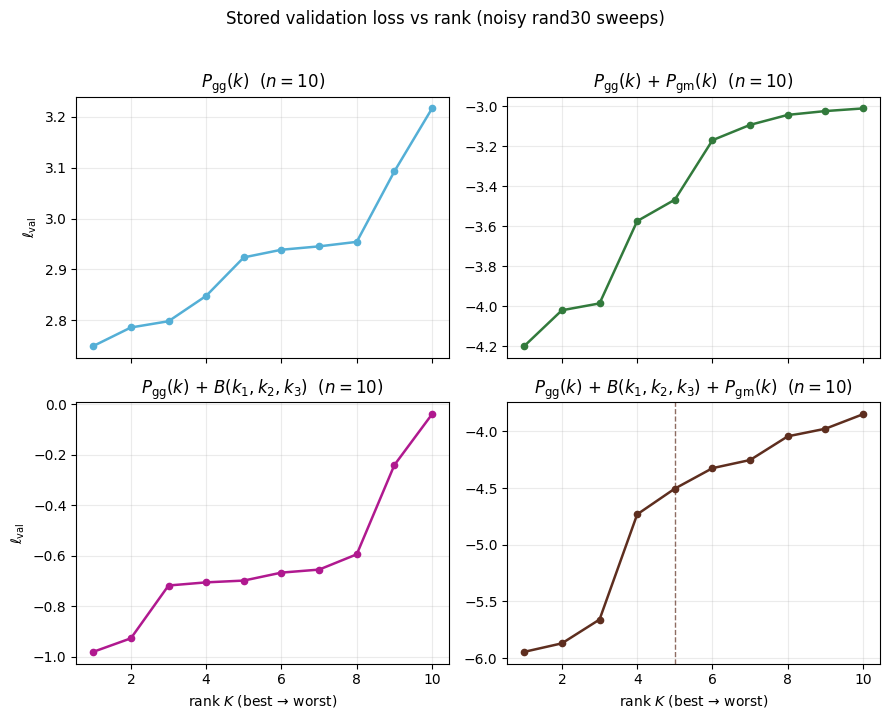

Stall filter: 10 passed, 3 failed, 17 untested (of 30 in log)
Top models — $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$:
  K= 1  zlf6r7gl    ell_val=-5.94402
  K= 2  ng1yr257    ell_val=-5.86913
  K= 3  rjjncomd    ell_val=-5.65921
  K= 4  fvje277c    ell_val=-4.7319
  K= 5  1ezbfbbs    ell_val=-4.50516


In [4]:
# Noisy rand30 sweeps — one panel per statistic combo (2×2)
STAT_COMBOS = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0), sharex=True, sharey=False)
axes = axes.ravel()

for ax, statistics_row in zip(axes, STAT_COMBOS):
    tags_mask_row = tags_mask_for_sweep(statistics_row)
    tag_inf_row = build_sweep_tag_inf(
        data_mode=data_mode,
        statistics=statistics_row,
        tags_mask=tags_mask_row,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=TAG_BIASPARAMS_TRAIN,
        tag_noise=TAG_NOISE_TRAIN,
        reparameterize=True,
        tag_sweep=TAG_SWEEP,
    )
    sweep_root_row = sweep_root_for_tag_inf(tag_inf_row)
    log_path = sweep_root_row / BEST_RUN_LOG_CSV
    if not log_path.is_file():
        ax.set_title(utils_plot.get_stat_label(statistics_row))
        ax.text(0.5, 0.5, "no best_run_log.csv", ha="center", va="center", transform=ax.transAxes)
        continue

    ell_rows = top_run_rows(sweep_root_row, n_top=10_000, require_stall_pass=True)
    ell_vals = np.array([r["best_val_loss"] for r in ell_rows], dtype=float)
    ranks = np.arange(1, len(ell_vals) + 1)
    color = utils_plot.get_stat_colors([statistics_row])[0]
    stat_label = utils_plot.get_stat_label(statistics_row)

    ax.plot(ranks, ell_vals, "o-", lw=1.8, ms=4.5, color=color)
    ax.set_title(f"{stat_label}  ($n={len(ell_vals)}$)")
    if statistics_row == statistics and len(ell_rows) >= N_TOP:
        ax.axvline(N_TOP, color=color, ls="--", lw=1, alpha=0.7)
    ax.grid(alpha=0.25)

for ax in axes[::2]:
    ax.set_ylabel(r"$\ell_\mathrm{val}$")
for ax in axes[2:]:
    ax.set_xlabel("rank $K$ (best → worst)")

fig.suptitle("Stored validation loss vs rank (noisy rand30 sweeps)", y=1.02)
fig.tight_layout()
plt.show()

# Print top-K for the notebook's primary combo only
ell_rows_primary = top_run_rows(sweep_root, n_top=max(N_TOP, 10), require_stall_pass=True)
print(f"Top models — {utils_plot.get_stat_label(statistics)}:")
for i, row in enumerate(ell_rows_primary[:N_TOP]):
    print(f"  K={i+1:2d}  {row['run_name']:10s}  ell_val={row['best_val_loss']:.6g}")


In [5]:
cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME,
    TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
)
theta_obs_true = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
theta_obs_true_show = theta_obs_true[idxs_zoom]

theta_cv = data_loader.load_theta_test(
    TAG_PARAMS_TEST_CV,
    TAG_BIASPARAMS_TEST_CV,
    cosmo_param_names_vary=cosmo_vary,
    bias_param_names_vary=bias_vary,
)
theta_cv_true = theta_cv[idx_obs] if theta_cv.ndim == 2 else theta_cv
theta_cv_true_show = theta_cv_true[idxs_zoom]
print("SHAMe OOD truth (zoom):", dict(zip(PARAM_NAMES_ZOOM, theta_obs_true_show)))
print("CV-mean truth (zoom):  ", dict(zip(PARAM_NAMES_ZOOM, theta_cv_true_show)))

SHAMe OOD truth (zoom): {'omega_cold': 0.30889999999999995, 'sigma8_cold': 0.8159000277519226, 'b1': 0.47410742}
CV-mean truth (zoom):   {'omega_cold': 0.3088999999999999, 'sigma8_cold': 0.8159, 'b1': 0.47410742}


## Load samples (top N)

Each run: `results_sbi/sbi<tag_inf_sweep>/<run_id>/samples_test<tag_test>_pred.npy` from `run_inference.py`.

In [6]:
def samples_to_matrix(samples: np.ndarray, idx_obs: int = 0) -> np.ndarray:
    """(n_samples, n_params) — same layout as get_samples_sbi for idx_obs."""
    s = np.asarray(samples)
    if s.ndim == 3:
        return s[:, idx_obs, :]
    if s.ndim == 2:
        return s
    raise ValueError(f"Unexpected samples shape {s.shape}")


def load_samples_for_run(run_name: str, tag_test_use: str | None = None) -> np.ndarray:
    out = samples_path(tag_sbi_run(run_name), tag_test_use=tag_test_use)
    if not out.is_file():
        raise FileNotFoundError(
            f"Missing {out}\n"
            f"Run submit_inf_test_topn.sh for this run (nth_best_run matches rank in top_rows)."
        )
    raw = np.load(out)
    samples = samples_to_matrix(raw)
    print(f"  loaded {out}  shape={samples.shape}")
    return samples


samples_by_run = {}
samples_cv_mean_by_run = {}
for i, row in enumerate(top_rows):
    rn = row["run_name"]
    print(f"[{i+1}/{N_TOP}] {rn}  SHAMe OOD")
    samples_by_run[rn] = load_samples_for_run(rn, tag_test_use=tag_test)
    print(f"[{i+1}/{N_TOP}] {rn}  CV mean")
    samples_cv_mean_by_run[rn] = load_samples_for_run(rn, tag_test_use=tag_test_cv_mean)

[1/5] zlf6r7gl  SHAMe OOD
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/zlf6r7gl/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy  shape=(10000, 11)
[1/5] zlf6r7gl  CV mean
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/zlf6r7gl/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy  shape=(10000, 11)
[2/5] ng1yr257  SHAMe OOD
  loaded /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/ng1yr257/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy  shape=(10000, 11)
[2/5] ng1yr257  CV mean
  loa

In [7]:
def mixture_sample_equal(rng: np.random.Generator, sample_dict: dict, n_total: int) -> np.ndarray:
    """Equal-weight mixture: n_total draws, each from a uniformly chosen run."""
    names = list(sample_dict.keys())
    n_per = n_total // len(names)
    remainder = n_total - n_per * len(names)
    chunks = []
    for j, name in enumerate(names):
        n_j = n_per + (1 if j < remainder else 0)
        s = samples_to_matrix(sample_dict[name])
        idx = rng.choice(s.shape[0], size=n_j, replace=(n_j > s.shape[0]))
        chunks.append(s[idx])
    out = np.vstack(chunks)
    rng.shuffle(out, axis=0)
    return out


def samples_for_rows(sample_dict: dict, rows: list[dict]) -> dict:
    return {r["run_name"]: sample_dict[r["run_name"]] for r in rows}


rng = np.random.default_rng(42)
top_rows_ensemble = top_rows[:N_ENSEMBLE_K]
samples_ensemble = mixture_sample_equal(
    rng, samples_for_rows(samples_by_run, top_rows_ensemble), N_ENSEMBLE
)
samples_ensemble_cv = mixture_sample_equal(
    rng, samples_for_rows(samples_cv_mean_by_run, top_rows_ensemble), N_ENSEMBLE
)
print(
    f"Ensemble mixture: {samples_ensemble.shape[0]} draws from "
    f"top {N_ENSEMBLE_K} of {len(samples_by_run)} plotted runs"
)

# Save mixture for plot_contours_inf (loads from disk; no inference)
tag_sbi_ensemble = f"{tag_inf_sweep}/{ENSEMBLE_RUN_NAME}"
ensemble_dir = dir_sbi_root / f"sbi{tag_sbi_ensemble}"
ensemble_dir.mkdir(parents=True, exist_ok=True)
src_pn = sweep_root / top_rows[0]["run_name"] / "param_names.txt"
dst_pn = ensemble_dir / "param_names.txt"
if not dst_pn.exists():
    dst_pn.write_bytes(src_pn.read_bytes())
ensemble_out = samples_path(tag_sbi_ensemble)
np.save(ensemble_out, samples_ensemble)
print(f"Ensemble saved for plotting: {ensemble_out}")

Ensemble mixture: 1000 draws from top 3 of 5 plotted runs
Ensemble saved for plotting: /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_sweep-rand30/_ensemble_top3_shame_noisy/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


## Consistency summary

In [8]:
def zoom_mean_std(samples: np.ndarray, pn_chain: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """Posterior mean/std in physical params (unreparameterize chain names first)."""
    s = samples_to_matrix(samples)
    su, names_u = utils_inference.unreparameterize_theta(s, list(pn_chain), strict=False)
    names_u = list(names_u)
    idx_show = [names_u.index(p) for p in PARAM_NAMES_ZOOM]
    block = su[:, idx_show]
    return block.mean(axis=0), block.std(axis=0)


pn_chain = list(np.loadtxt(sweep_root / top_rows[0]["run_name"] / "param_names.txt", dtype=str))

rows_summary = []
for row in top_rows:
    m, sd = zoom_mean_std(samples_by_run[row["run_name"]], pn_chain)
    rows_summary.append((row["run_name"], m, sd))

m_e, sd_e = zoom_mean_std(samples_ensemble, pn_chain)
rows_summary.append(("ensemble", m_e, sd_e))

hdr = "run".ljust(12) + "".join(f"{p:>18s}" for p in PARAM_NAMES_ZOOM)
print(hdr)
print("means")
for name, m, _ in rows_summary:
    print(name.ljust(12) + "".join(f"{v:18.4f}" for v in m))
print("stds")
for name, _, sd in rows_summary:
    print(name.ljust(12) + "".join(f"{v:18.4f}" for v in sd))

spread = np.std([m for _, m, _ in rows_summary[:-1]], axis=0)
print(f"\nSpread of top-{N_TOP} posterior means (per param):", dict(zip(PARAM_NAMES_ZOOM, spread)))

run                 omega_cold       sigma8_cold                b1
means
zlf6r7gl                0.3070            0.7889            0.4768
ng1yr257                0.3058            0.7915            0.4662
rjjncomd                0.3135            0.7891            0.4759
fvje277c                0.3129            0.7900            0.4649
1ezbfbbs                0.3082            0.7899            0.4692
ensemble                0.3088            0.7900            0.4727
stds
zlf6r7gl                0.0139            0.0084            0.0141
ng1yr257                0.0140            0.0098            0.0206
rjjncomd                0.0149            0.0091            0.0158
fvje277c                0.0142            0.0096            0.0185
1ezbfbbs                0.0136            0.0097            0.0189
ensemble                0.0144            0.0090            0.0179

Spread of top-5 posterior means (per param): {'omega_cold': 0.0031371074207706883, 'sigma8_cold': 0.00094491084172430

## Diagnostics

Check loaded sample counts, physical posterior ranges vs axis limits, and truth.

## Corner plots (colored by validation loss)

Two overlays of the top-$N$ stall-passing runs, colored by $\ell_{\mathrm{val}}$ (min validation loss): **SHAMe OOD** and **fixed-cosmo cosmic-variance mean**. Missing sample files raise an error (run `submit_inf_test_topn.sh`).

In [25]:
def print_posterior_diagnostics(run_name: str, samples: np.ndarray, pn_chain: list[str]) -> None:
    s = samples_to_matrix(samples)
    su, names_u = utils_inference.unreparameterize_theta(s, pn_chain, strict=False)
    names_u = list(names_u)
    print(f"--- {run_name}  n_samples={s.shape[0]} ---")
    for pn in PARAM_NAMES_ZOOM:
        if pn not in names_u:
            print(f"  {pn}: MISSING from chain")
            continue
        col = su[:, names_u.index(pn)]
        lo, hi = EXTENTS_CORNER.get(pn, extents.get(pn, (None, None)))
        q = np.percentile(col, [5, 50, 95])
        in_range = (lo is None or q[0] >= lo) and (hi is None or q[2] <= hi)
        flag = "" if in_range else "  ** OUTSIDE EXTENTS_CORNER **"
        print(
            f"  {pn:14s}  q05={q[0]:.4f}  q50={q[1]:.4f}  q95={q[2]:.4f}  "
            f"extent=[{lo}, {hi}]{flag}"
        )
    if theta_obs_true_show is not None:
        print("  truth (zoom):", dict(zip(PARAM_NAMES_ZOOM, theta_obs_true_show)))


pn_chain = list(np.loadtxt(sweep_root / top_rows[0]["run_name"] / "param_names.txt", dtype=str))
for row in top_rows:
    print_posterior_diagnostics(row["run_name"], samples_by_run[row["run_name"]], pn_chain)
print(f"\nPlot axes: EXTENTS_CORNER (not extents_narrow — narrow sigma8 cuts off SHAMe OOD ~0.68)")

--- zlf6r7gl  n_samples=10000 ---
  omega_cold      q05=0.2842  q50=0.3070  q95=0.3299  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7750  q50=0.7889  q95=0.8027  extent=[0.65, 0.9]
  b1              q05=0.4526  q50=0.4773  q95=0.4991  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 0.30889999999999995, 'sigma8_cold': 0.8159000277519226, 'b1': 0.47410742}
--- ng1yr257  n_samples=10000 ---
  omega_cold      q05=0.2827  q50=0.3058  q95=0.3289  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7758  q50=0.7913  q95=0.8079  extent=[0.65, 0.9]
  b1              q05=0.4306  q50=0.4676  q95=0.4977  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 0.30889999999999995, 'sigma8_cold': 0.8159000277519226, 'b1': 0.47410742}
--- rjjncomd  n_samples=10000 ---
  omega_cold      q05=0.2888  q50=0.3133  q95=0.3377  extent=[0.23, 0.4]
  sigma8_cold     q05=0.7742  q50=0.7890  q95=0.8040  extent=[0.65, 0.9]
  b1              q05=0.4494  q50=0.4762  q95=0.5005  extent=[-0.4, 1.4]
  truth (zoom): {'omega_cold': 

ℓ_val range: [-5.944, -4.505]  (best=zlf6r7gl)


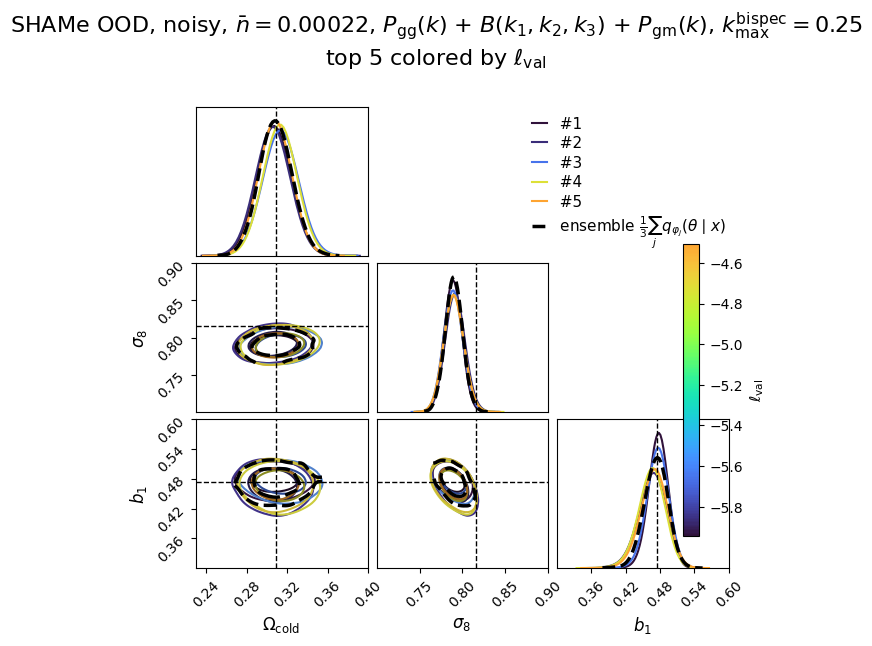

ℓ_val range: [-5.944, -4.505]  (best=zlf6r7gl)


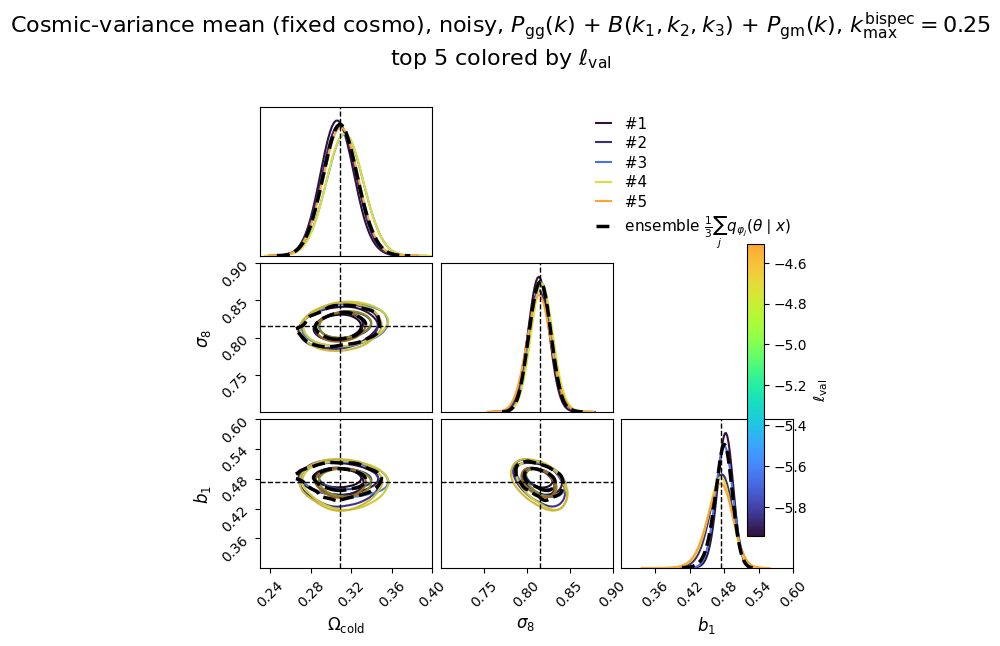

In [26]:
def truncate_cmap(cmap, max_frac=LVAL_CMAP_MAX, n=256):
    """Use cmap[0:max_frac] only (e.g. turbo without the red end)."""
    return mcolors.LinearSegmentedColormap.from_list(
        f"{cmap.name}_0_{max_frac}", cmap(np.linspace(0.0, max_frac, n))
    )


def colors_by_val_loss(rows, cmap_name=LVAL_CMAP):
    """Map best_val_loss → hex colors; lower (better) loss → lower cmap value."""
    losses = np.asarray([r["best_val_loss"] for r in rows], dtype=float)
    cmap = truncate_cmap(plt.get_cmap(cmap_name))
    norm = mcolors.Normalize(vmin=float(np.min(losses)), vmax=float(np.max(losses)))
    colors = [mcolors.to_hex(cmap(norm(L))) for L in losses]
    return colors, losses, cmap, norm


def add_loss_colorbar(fig, cmap, norm, label=r"$\ell_{\mathrm{val}}$"):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.88, 0.18, 0.025, 0.45])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label(label, fontsize=FONTSIZE_LEGEND)
    cb.ax.tick_params(labelsize=FONTSIZE_LEGEND - 1)
    return cb


def plot_topn_loss_contours(
    sample_dict,
    *,
    theta_true_show,
    extents_use,
    title,
    tag_test_use,
    rows=None,
    samples_ensemble=None,
    label_ensemble="ensemble",
):
    rows = top_rows if rows is None else list(rows)
    pn_chain = list(
        np.loadtxt(sweep_root / top_rows[0]["run_name"] / "param_names.txt", dtype=str)
    )
    colors, losses, cmap, norm = colors_by_val_loss(rows)
    tags_inf = [tag_sbi_run(r["run_name"]) for r in rows]
    samples_list = [
        (samples_to_matrix(sample_dict[r["run_name"]]), pn_chain) for r in rows
    ]
    labels = [f"#{i+1}" for i in range(len(rows))]
    linestyles = None
    linewidths = None
    if samples_ensemble is not None:
        samples_list.append((samples_to_matrix(samples_ensemble), pn_chain))
        colors = list(colors) + ["#000000"]
        labels = labels + [label_ensemble]
        tags_inf = tags_inf + ["_ensemble"]
        linestyles = ["-"] * len(rows) + ["--"]
        linewidths = [1.5] * len(rows) + [2.5]
    n_plot = len(samples_list)

    fig = plotter.plot_contours_inf(
        param_names=PARAM_NAMES_ZOOM,
        idx_obs=idx_obs,
        theta_obs_true=theta_true_show,
        inf_methods=["sbi"] * n_plot,
        tags_inf=tags_inf,
        tags_test=[tag_test_use] * n_plot,
        colors=colors,
        labels=labels,
        title=title,
        extents=extents_use,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
        samples_list=samples_list,
        show=False,
        linestyles=linestyles,
        linewidths=linewidths,
    )
    add_loss_colorbar(fig, cmap, norm)
    print(
        f"ℓ_val range: [{losses.min():.4g}, {losses.max():.4g}]  "
        f"(best={rows[0]['run_name']})"
    )
    plt.show()


title_shame = (
    f"SHAMe OOD, {NOISE_MODE}, $\\bar n={NBAR_LABEL}$, {stat_label}\n"
    f"top {N_TOP} colored by $\\ell_{{\\mathrm{{val}}}}$"
)
plot_topn_loss_contours(
    samples_by_run,
    theta_true_show=theta_obs_true_show,
    extents_use=extents_narrow,
    title=title_shame,
    tag_test_use=tag_test,
    samples_ensemble=samples_ensemble,
    label_ensemble=LABEL_ENSEMBLE,
)

title_cv = (
    f"Cosmic-variance mean (fixed cosmo), {NOISE_MODE}, {stat_label}\n"
    f"top {N_TOP} colored by $\\ell_{{\\mathrm{{val}}}}$"
)
plot_topn_loss_contours(
    samples_cv_mean_by_run,
    theta_true_show=theta_cv_true_show,
    extents_use=extents_narrow,
    title=title_cv,
    tag_test_use=tag_test_cv_mean,
    samples_ensemble=samples_ensemble_cv,
    label_ensemble=LABEL_ENSEMBLE,
)


## Fiducial $k_\mathrm{max}$ retraining ($k_\mathrm{max}^\mathrm{bispec}=k_\mathrm{max}^{P_{gm}}=0.25$)

Retrain the **top 5** stall-passing sweep networks (lowest $\ell_\mathrm{val}$) on the new fiducial masks for contours; ensemble = equal mix of the **top 3**. Plot SHAMe OOD and CV-mean posteriors plus the mixture

$$q_\varphi(\theta\mid x)=\frac{1}{5}\sum_{j=1}^{5} q_{\varphi_j}(\theta\mid x).$$

Training/testing: `bash code/submit_inf_train_test_topn_kfid.sh` (`run_mode=best`, `nth_best_run=0..4`). Missing sample files raise an error.

kfid tag_inf example: _muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest0
SHAMe tag_test kfid: _shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022
CV-mean tag_test kfid: _muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean
Top-5 hparams (val-loss rank → retrained nbest):
  nbest0  zlf6r7gl  ℓ_val=-5.94402
  nbest1  ng1yr257  ℓ_val=-5.86913
  nbest2  rjjncomd  ℓ_val=-5.65921
  nbest3  fvje277c  ℓ_val=-4.7319
  nbest4  1ezbfbbs  ℓ_val=-4.50516
[1/5] zlf6r7gl  _muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest0
  loaded OOD samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy  shape=(10000, 11)
  loaded CV samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy  

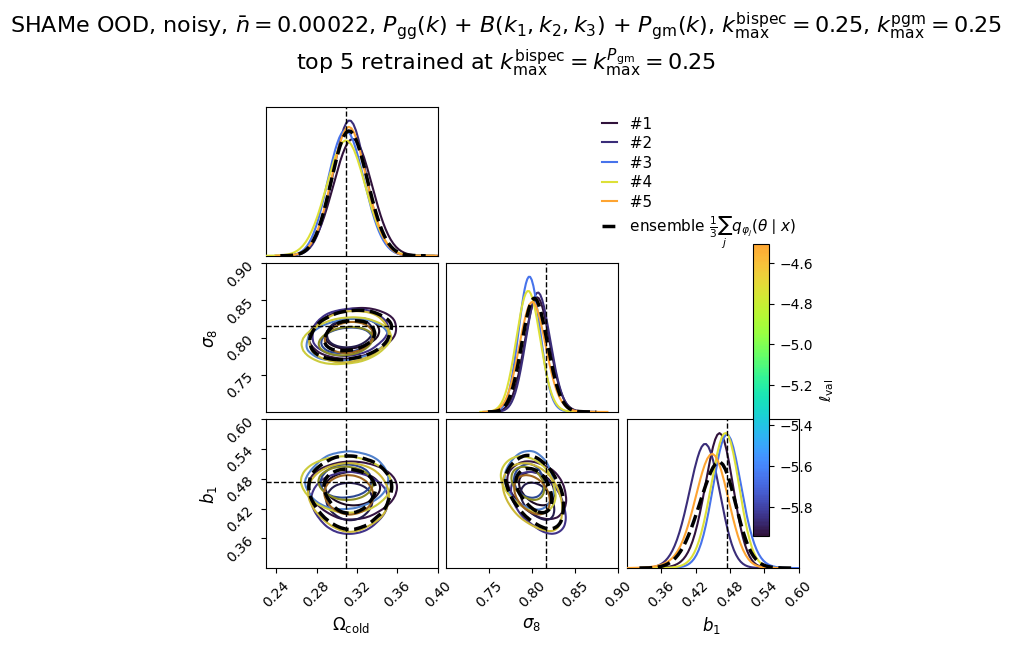

ℓ_val range: [-5.944, -4.505]  (best=zlf6r7gl)


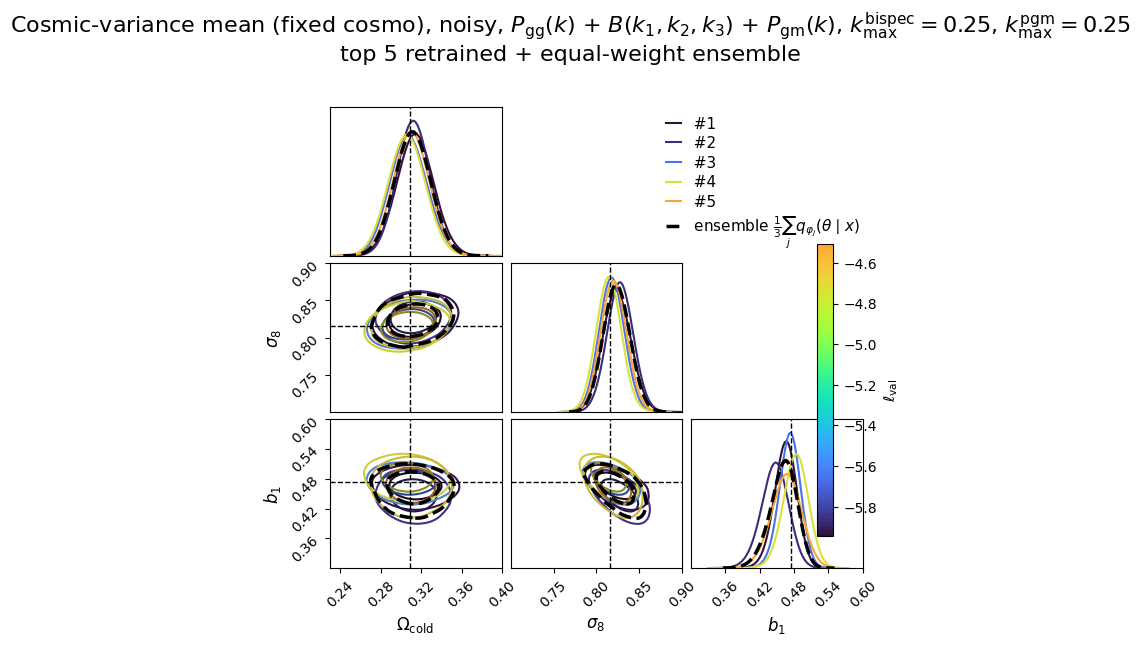

In [28]:
N_TOP_KFID = N_TOP
N_ENSEMBLE_KFID = 5000
LABEL_ENSEMBLE_KFID = rf"ensemble $\frac{{1}}{{{N_ENSEMBLE_K}}}\sum_j q_{{\varphi_j}}(\theta\mid x)$"
SCRIPT_KFID = REPO_ROOT / "code" / "submit_inf_train_test_topn_kfid.sh"

tags_mask_kfid = ["", "_kb0.25", "_kpgm0.25"]
tag_data_kfid = build_tag_data(
    data_mode,
    statistics,
    tags_mask_kfid,
    TAG_PARAMS_TRAIN,
    TAG_BIASPARAMS_TRAIN,
    TAG_NOISE_TRAIN,
)
base_inf_kfid = tag_data_kfid + tag_reparam + f"_bx{bx}_ntrain{n_train}"


def tag_inf_kfid(n: int) -> str:
    return f"{base_inf_kfid}_best{TAG_SWEEP}_nbest{n}"


tag_stats_kfid = "_" + "_".join(statistics) + "".join(tags_mask_kfid)
tag_test_kfid = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=[tag_stats_kfid],
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)[0]
tag_test_cv_mean_kfid = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_CV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_CV,
    tag_stats_arr=["_" + "_".join(statistics)],
    tag_datagen_test="_mean",
    tag_noise_test=TAG_NOISE_TEST_CV,
    tags_mask_test=["".join(tags_mask_kfid)],
)[0]
stat_label_kfid = (
    utils_plot.get_stat_label(statistics)
    + f", {utils_plot.get_mask_label(''.join(tags_mask_kfid))}"
)

top_rows_kfid = top_rows[:N_TOP_KFID]
print("kfid tag_inf example:", tag_inf_kfid(0))
print("SHAMe tag_test kfid:", tag_test_kfid)
print("CV-mean tag_test kfid:", tag_test_cv_mean_kfid)
print(f"Top-{N_TOP_KFID} hparams (val-loss rank → retrained nbest):")
for i, row in enumerate(top_rows_kfid):
    print(f"  nbest{i}  {row['run_name']}  ℓ_val={row['best_val_loss']:.6g}")

samples_by_run_kfid = {}
samples_cv_mean_by_run_kfid = {}
missing_kfid = []
for i, row in enumerate(top_rows_kfid):
    rn = row["run_name"]
    tag_inf = tag_inf_kfid(i)
    path_ood = samples_path(tag_inf, tag_test_kfid)
    path_cv = samples_path(tag_inf, tag_test_cv_mean_kfid)
    print(f"[{i+1}/{N_TOP_KFID}] {rn}  {tag_inf}")
    if not path_ood.is_file():
        missing_kfid.append(str(path_ood))
        print(f"  missing SHAMe OOD: {path_ood}")
    else:
        samples_by_run_kfid[rn] = samples_to_matrix(np.load(path_ood))
        print(f"  loaded OOD {path_ood.name}  shape={samples_by_run_kfid[rn].shape}")
    if not path_cv.is_file():
        missing_kfid.append(str(path_cv))
        print(f"  missing CV mean: {path_cv}")
    else:
        samples_cv_mean_by_run_kfid[rn] = samples_to_matrix(np.load(path_cv))
        print(f"  loaded CV {path_cv.name}  shape={samples_cv_mean_by_run_kfid[rn].shape}")

if missing_kfid:
    raise FileNotFoundError(
        "Missing kfid posterior samples. Run:\n"
        f"  bash {SCRIPT_KFID}\n"
        "then re-run this cell. Missing files:\n  " + "\n  ".join(missing_kfid)
    )

rng_kfid = np.random.default_rng(123)
top_rows_kfid_ensemble = top_rows_kfid[:N_ENSEMBLE_K]
samples_ensemble_kfid = mixture_sample_equal(
    rng_kfid,
    samples_for_rows(samples_by_run_kfid, top_rows_kfid_ensemble),
    N_ENSEMBLE_KFID,
)
samples_ensemble_cv_kfid = mixture_sample_equal(
    rng_kfid,
    samples_for_rows(samples_cv_mean_by_run_kfid, top_rows_kfid_ensemble),
    N_ENSEMBLE_KFID,
)
print(
    f"kfid ensemble: {samples_ensemble_kfid.shape[0]} draws from "
    f"top {N_ENSEMBLE_K} of {len(samples_by_run_kfid)} plotted flows"
)

title_shame_kfid = (
    f"SHAMe OOD, {NOISE_MODE}, $\\bar n={NBAR_LABEL}$, {stat_label_kfid}\n"
    f"top {N_TOP_KFID} retrained at $k_\\mathrm{{max}}^\\mathrm{{bispec}}"
    f"=k_\\mathrm{{max}}^{{P_\\mathrm{{gm}}}}=0.25$"
)
plot_topn_loss_contours(
    samples_by_run_kfid,
    theta_true_show=theta_obs_true_show,
    extents_use=extents_narrow,
    title=title_shame_kfid,
    tag_test_use=tag_test_kfid,
    rows=top_rows_kfid,
    samples_ensemble=samples_ensemble_kfid,
    label_ensemble=LABEL_ENSEMBLE_KFID,
)

title_cv_kfid = (
    f"Cosmic-variance mean (fixed cosmo), {NOISE_MODE}, {stat_label_kfid}\n"
    f"top {N_TOP_KFID} retrained + equal-weight ensemble"
)
plot_topn_loss_contours(
    samples_cv_mean_by_run_kfid,
    theta_true_show=theta_cv_true_show,
    extents_use=extents_narrow,
    title=title_cv_kfid,
    tag_test_use=tag_test_cv_mean_kfid,
    rows=top_rows_kfid,
    samples_ensemble=samples_ensemble_cv_kfid,
    label_ensemble=LABEL_ENSEMBLE_KFID,
)

## FoM / FoB (fiducial $k_\mathrm{max}$, lowest val-loss vs ensemble)

3D FoM/FoB on physical $(\Omega_\mathrm{c},\sigma_8,b_1)$ from unreparameterized posterior samples (mean + covariance). Lowest val-loss = `nbest0`; ensemble = equal mix of `nbest0`–`2`. FoB$_{3\mathrm{D}}$ is divided by $\sqrt{\chi^2_{\nu=3}(0.68)}\approx 1.88$ so that 1 = $1\sigma$.

In [29]:
from scipy.stats import chi2

PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "b1"]
FOB_KEYS = ["omega_c", "sigma8", "b1"]
FOB_RIDGE = 1e-8
# Same 1σ factor as paper figures: FoB_3D / √χ²_{ν=3}(68%) so 1 = 1σ.
_CHI2_PPF_1SIG = 0.682689492137
FOB3_NORM = float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, 3)))


def _fom_fob_from_samples(samples, param_names, theta_true_phys, param_vary):
    samples_u, names_u = utils_inference.unreparameterize_theta(samples, param_names, strict=True)
    names_u = [str(n) for n in names_u]
    idx = [names_u.index(pn) for pn in PARAM_NAMES_FOB]
    block = np.asarray(samples_u)[:, idx]
    mu = block.mean(axis=0)
    cov = np.cov(block.T)
    true = np.array([float(theta_true_phys[list(param_vary).index(pn)]) for pn in PARAM_NAMES_FOB])
    cov_r = cov + FOB_RIDGE * np.eye(len(idx))
    sig = np.sqrt(np.diag(cov_r))
    fob_1d = np.abs(mu - true) / sig
    diff = mu - true
    sign, _ = np.linalg.slogdet(cov_r)
    cov_inv = np.linalg.inv(cov_r) if sign > 0 else np.linalg.pinv(cov_r)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff)) / FOB3_NORM
    det = np.linalg.det(cov)
    fom3 = float(1.0 / np.sqrt(det)) if det > 0 else np.nan
    return {
        "fom3": fom3,
        "fob3": fob3,
        "fom_1d": 1.0 / sig,
        "fob_1d": fob_1d,
        "mu": mu,
        "true": true,
        "sig": sig,
    }


def _print_fom_fob(title, r):
    print(title)
    print(f"  FoM_3D (Ωc, σ8, b1) = {r['fom3']:.6g}")
    print(f"  FoB_3D / √χ²_3(68%) (Ωc, σ8, b1) = {r['fob3']:.4f}   [1 = 1σ]")
    for i, k in enumerate(FOB_KEYS):
        print(
            f"    {k:8s}  mu={r['mu'][i]:.5f}  true={r['true'][i]:.5f}  "
            f"sig={r['sig'][i]:.5f}  FoM_1D={r['fom_1d'][i]:.4g}  FoB_1D={r['fob_1d'][i]:.3f}"
        )


# Prefer in-memory kfid samples from the previous cell; otherwise load nbest0–2.
if "samples_by_run_kfid" not in globals() or "samples_ensemble_kfid" not in globals():
    raise RuntimeError("Run the fiducial kmax cell first (loads nbest0–2 samples).")

_pn_kfid = list(
    np.loadtxt(
        dir_sbi_root / f"sbi{tag_inf_kfid(0)}" / "param_names.txt", dtype=str
    )
)
_best_run = top_rows_kfid[0]["run_name"]

print(f"lowest val-loss: nbest0  {_best_run}  ℓ_val={top_rows_kfid[0]['best_val_loss']:.6g}")
print(f"ensemble: equal mix of nbest0–{N_TOP_KFID - 1}")
print(f"FoB_3D norm √χ²_3(68%) = {FOB3_NORM:.4f}  (divide so 1 = 1σ)\n")
print("========== SHAMe OOD ==========")
_print_fom_fob(
    "lowest val-loss:",
    _fom_fob_from_samples(
        samples_by_run_kfid[_best_run], _pn_kfid, theta_obs_true, param_vary
    ),
)
_print_fom_fob(
    "ensemble:",
    _fom_fob_from_samples(samples_ensemble_kfid, _pn_kfid, theta_obs_true, param_vary),
)
print("\n========== Cosmic-variance mean ==========")
_print_fom_fob(
    "lowest val-loss:",
    _fom_fob_from_samples(
        samples_cv_mean_by_run_kfid[_best_run], _pn_kfid, theta_cv_true, param_vary
    ),
)
_print_fom_fob(
    "ensemble:",
    _fom_fob_from_samples(
        samples_ensemble_cv_kfid, _pn_kfid, theta_cv_true, param_vary
    ),
)

lowest val-loss: nbest0  zlf6r7gl  ℓ_val=-5.94402
ensemble: equal mix of nbest0–4
FoB_3D norm √χ²_3(68%) = 1.8780  (divide so 1 = 1σ)

========== SHAMe OOD ==========
lowest val-loss:
  FoM_3D (Ωc, σ8, b1) = 299268
  FoB_3D / √χ²_3(68%) (Ωc, σ8, b1) = 0.8866   [1 = 1σ]
    omega_c   mu=0.31564  true=0.30890  sig=0.01569  FoM_1D=63.74  FoB_1D=0.430
    sigma8    mu=0.80585  true=0.81590  sig=0.01227  FoM_1D=81.5  FoB_1D=0.819
    b1        mu=0.45962  true=0.47411  sig=0.02013  FoM_1D=49.69  FoB_1D=0.720
ensemble:
  FoM_3D (Ωc, σ8, b1) = 244495
  FoB_3D / √χ²_3(68%) (Ωc, σ8, b1) = 0.9936   [1 = 1σ]
    omega_c   mu=0.31285  true=0.30890  sig=0.01501  FoM_1D=66.64  FoB_1D=0.263
    sigma8    mu=0.80313  true=0.81590  sig=0.01226  FoM_1D=81.53  FoB_1D=1.041
    b1        mu=0.45635  true=0.47411  sig=0.02679  FoM_1D=37.33  FoB_1D=0.663

========== Cosmic-variance mean ==========
lowest val-loss:
  FoM_3D (Ωc, σ8, b1) = 399596
  FoB_3D / √χ²_3(68%) (Ωc, σ8, b1) = 0.3648   [1 = 1σ]
    omeg

## FoM / FoB for $P_{gg}+P_{gm}$ ($k_\mathrm{max}^{P_{gm}}=0.25$)

Same 3D FoM/FoB as above, for the noisy $P_{gg}+P_{gm}$ sweep (top 5 contours, top-3 ensemble by val loss) retrained at fiducial $k_\mathrm{max}^{P_{gm}}=0.25$. Lowest val-loss = `nbest0` (same as `_best-rand30`); ensemble = equal mix of `nbest0`–`2`. Train/test: `bash code/submit_inf_train_test_topn_pkpgm.sh`.

In [30]:
# P_gg + P_gm at kpgm0.25 (top-5 contours, top-3 ensemble; nbest0 = existing _best-rand30)
stats_pgm = ["pk", "pgm"]
masks_pgm = ["", "_kpgm0.25"]
N_TOP_PGM = N_TOP
N_ENSEMBLE_PGM = 5000

tag_data_pgm = build_tag_data(
    data_mode, stats_pgm, masks_pgm,
    TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, TAG_NOISE_TRAIN,
)
base_inf_pgm = tag_data_pgm + tag_reparam + f"_bx{bx}_ntrain{n_train}"


def tag_inf_pgm(n: int) -> str:
    return f"{base_inf_pgm}_best{TAG_SWEEP}_nbest{n}"


tag_stats_pgm = "_" + "_".join(stats_pgm) + "".join(masks_pgm)
tag_test_pgm = utils_plot.setup_shame_mock_test_tags(
    tag_stats_arr=[tag_stats_pgm],
    data_mode_test=DATA_MODE_TEST_SHAME,
    tag_mock=TAG_MOCK_SHAME,
)[0]
tag_test_cv_pgm = utils_plot.setup_test_tags(
    data_mode=data_mode,
    tag_params_test=TAG_PARAMS_TEST_CV,
    tags_biasparams_test=TAG_BIASPARAMS_TEST_CV,
    tag_stats_arr=["_" + "_".join(stats_pgm)],
    tag_datagen_test="_mean",
    tag_noise_test=TAG_NOISE_TEST_CV,
    tags_mask_test=["".join(masks_pgm)],
)[0]

tag_inf_sweep_pgm = build_sweep_tag_inf(
    data_mode=data_mode,
    statistics=stats_pgm,
    tags_mask=tags_mask_for_sweep(stats_pgm),
    tag_params=TAG_PARAMS_TRAIN,
    tag_biasparams=TAG_BIASPARAMS_TRAIN,
    tag_noise=TAG_NOISE_TRAIN,
    reparameterize=True,
    tag_sweep=TAG_SWEEP,
)
pgm_rows = load_best_run_log(sweep_root_for_tag_inf(tag_inf_sweep_pgm))[:N_TOP_PGM]
print("Pgg+Pgm tag_inf nbest0:", tag_inf_pgm(0))
print("SHAMe tag_test:", tag_test_pgm)
print("CV-mean tag_test:", tag_test_cv_pgm)
print(f"Top-{N_TOP_PGM} by val loss (pk+pgm sweep):")
for i, row in enumerate(pgm_rows):
    print(f"  nbest{i}  {row['run_name']}  ℓ_val={row['best_val_loss']:.6g}  stall={row['pass_stall_test'] or 'untested'}")

samples_by_run_pgm = {}
samples_cv_mean_by_run_pgm = {}
missing_pgm = []
for i, row in enumerate(pgm_rows):
    rn = row["run_name"]
    tag_inf = tag_inf_pgm(i)
    path_ood = samples_path(tag_inf, tag_test_pgm)
    path_cv = samples_path(tag_inf, tag_test_cv_pgm)
    print(f"[{i+1}/{N_TOP_PGM}] {rn}  {tag_inf}")
    if not path_ood.is_file():
        missing_pgm.append(str(path_ood))
        print(f"  missing SHAMe OOD: {path_ood}")
    else:
        samples_by_run_pgm[rn] = samples_to_matrix(np.load(path_ood))
        print(f"  loaded OOD {path_ood.name}  shape={samples_by_run_pgm[rn].shape}")
    if not path_cv.is_file():
        missing_pgm.append(str(path_cv))
        print(f"  missing CV mean: {path_cv}")
    else:
        samples_cv_mean_by_run_pgm[rn] = samples_to_matrix(np.load(path_cv))
        print(f"  loaded CV {path_cv.name}  shape={samples_cv_mean_by_run_pgm[rn].shape}")

_pn_pgm = list(np.loadtxt(dir_sbi_root / f"sbi{tag_inf_pgm(0)}" / "param_names.txt", dtype=str))
_best_pgm = pgm_rows[0]["run_name"]
print(f"\nlowest val-loss: nbest0  {_best_pgm}  ℓ_val={pgm_rows[0]['best_val_loss']:.6g}")
print(f"FoB_3D norm √χ²_3(68%) = {FOB3_NORM:.4f}  (divide so 1 = 1σ)\n")

print("========== SHAMe OOD  |  Pgg + Pgm ==========")
_print_fom_fob(
    "lowest val-loss:",
    _fom_fob_from_samples(samples_by_run_pgm[_best_pgm], _pn_pgm, theta_obs_true, param_vary),
)
print("\n========== Cosmic-variance mean  |  Pgg + Pgm ==========")
_print_fom_fob(
    "lowest val-loss:",
    _fom_fob_from_samples(samples_cv_mean_by_run_pgm[_best_pgm], _pn_pgm, theta_cv_true, param_vary),
)

have_ens_pgm = (
    len(samples_by_run_pgm) >= N_ENSEMBLE_K
    and len(samples_cv_mean_by_run_pgm) >= N_ENSEMBLE_K
)
if not have_ens_pgm:
    print(
        f"\nEnsemble skipped: need nbest0–{N_ENSEMBLE_K - 1} samples. "
        "Re-run after `bash code/submit_inf_train_test_topn_pkpgm.sh` finishes."
    )
    if missing_pgm:
        print("Missing files:")
        for p in missing_pgm:
            print(" ", p)
else:
    pgm_rows_ensemble = pgm_rows[:N_ENSEMBLE_K]
    rng_pgm = np.random.default_rng(123)
    samples_ensemble_pgm = mixture_sample_equal(
        rng_pgm, samples_for_rows(samples_by_run_pgm, pgm_rows_ensemble), N_ENSEMBLE_PGM
    )
    samples_ensemble_cv_pgm = mixture_sample_equal(
        rng_pgm,
        samples_for_rows(samples_cv_mean_by_run_pgm, pgm_rows_ensemble),
        N_ENSEMBLE_PGM,
    )
    print("\n========== SHAMe OOD  |  Pgg + Pgm ensemble ==========")
    _print_fom_fob(
        "ensemble:",
        _fom_fob_from_samples(samples_ensemble_pgm, _pn_pgm, theta_obs_true, param_vary),
    )
    print("\n========== Cosmic-variance mean  |  Pgg + Pgm ensemble ==========")
    _print_fom_fob(
        "ensemble:",
        _fom_fob_from_samples(samples_ensemble_cv_pgm, _pn_pgm, theta_cv_true, param_vary),
    )

Pgg+Pgm tag_inf nbest0: _muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest0
SHAMe tag_test: _shame_pk_pgm_kpgm0.25_nbar0.00022
CV-mean tag_test: _muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean
Top-5 by val loss (pk+pgm sweep):
  nbest0  smrvlrc1  ℓ_val=-4.19784  stall=true
  nbest1  bni2poiq  ℓ_val=-4.01924  stall=true
  nbest2  6agtv9ev  ℓ_val=-3.985  stall=true
  nbest3  hrvd8uwd  ℓ_val=-3.57419  stall=true
  nbest4  57tmtp5o  ℓ_val=-3.46736  stall=true
[1/5] smrvlrc1  _muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30_nbest0
  loaded OOD samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy  shape=(10000, 11)
  loaded CV samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisebest_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy  shape=(10000, 11)
[2/5] bni2poiq  _muchisimocks_